In [1]:
import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder
from sklearn.linear_model import LinearRegression
from sklearn.metrics import root_mean_squared_error, mean_absolute_error

- Importing the dataset

In [2]:
df=pd.read_csv('job_salary_prediction_dataset.csv')
df

,job_title,experience_years,education_level,skills_count,industry,company_size,location,remote_work,certifications,salary
0,AI Engineer,10,Bachelor,2,Healthcare,Medium,India,Hybrid,2,109413
1,Data Analyst,5,Bachelor,17,Telecom,Small,Australia,No,0,93764
2,Frontend Developer,18,PhD,4,Media,Medium,Singapore,No,1,148123
3,Business Analyst,19,PhD,13,Retail,Medium,Canada,Yes,0,189123
4,Product Manager,15,Bachelor,7,Manufacturing,Large,Sweden,Yes,0,165069
...,...,...,...,...,...,...,...,...,...,...
249995,Software Engineer,17,PhD,2,Telecom,Enterprise,India,No,1,127791
249996,Frontend Developer,20,PhD,7,Telecom,Startup,Remote,No,2,154593
249997,Business Analyst,1,Bachelor,12,Retail,Enterprise,India,Yes,0,75988
249998,Data Scientist,0,High School,2,Consulting,Small,Sweden,Hybrid,5,90467


- Splitting x and y

In [3]:
x=df.drop(columns='salary')
y=df['salary']

- Segregating numerical and categorical columns and storing the columns names in seperate variables

In [4]:
num_cols=x.select_dtypes(include='number').columns
num_cols

Index(['experience_years', 'skills_count', 'certifications'], dtype='object')

In [5]:
obj_cols=x.select_dtypes(include='object').columns
obj_cols

Index(['job_title', 'education_level', 'industry', 'company_size', 'location',
       'remote_work'],
      dtype='object')

- Splitting the data into train data(seen data) and test data(unseen data)

In [6]:
xtrain,xtest,ytrain,ytest=train_test_split(x,y,train_size=0.8,random_state=42)
xtrain

,job_title,experience_years,education_level,skills_count,industry,company_size,location,remote_work,certifications
75381,Machine Learning Engineer,4,Diploma,14,Technology,Medium,India,Yes,5
65569,Backend Developer,1,PhD,6,Consulting,Large,Sweden,Yes,1
163473,Backend Developer,16,High School,3,Manufacturing,Medium,Canada,No,1
90518,Data Analyst,4,High School,18,Finance,Startup,UK,Hybrid,4
138866,Backend Developer,7,Diploma,8,Retail,Medium,Germany,No,0
...,...,...,...,...,...,...,...,...,...
119879,Machine Learning Engineer,3,Diploma,5,Education,Startup,India,No,0
103694,Cybersecurity Analyst,7,Bachelor,6,Government,Enterprise,Netherlands,Yes,4
131932,Frontend Developer,6,PhD,6,Media,Large,Australia,Hybrid,0
146867,Data Analyst,7,High School,8,Retail,Medium,Sweden,No,2


- Ploting a boxplot graph to check the outliers are present or not in the train data 

<Axes: >

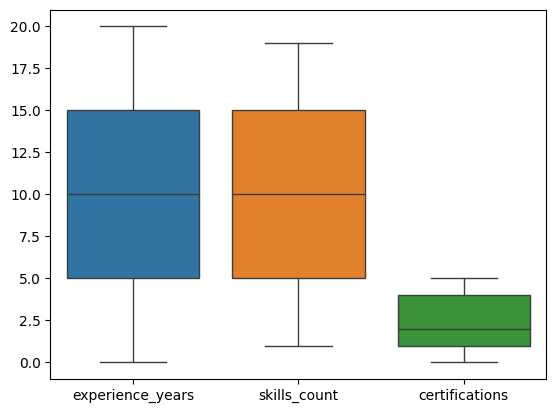

In [7]:
sns.boxplot(x[num_cols])

In [8]:
df.corr(numeric_only=True)

,experience_years,skills_count,certifications,salary
experience_years,1.000000,0.000149,-0.000198,0.437627
skills_count,0.000149,1.000000,-0.002230,0.127300
certifications,-0.000198,-0.002230,1.000000,0.073819
salary,0.437627,0.127300,0.073819,1.000000


- As we can see in the above graphs there are no outliers so we can use Normalization method for scaling i.e using MixMaxScaler.

In [9]:
scaling=MinMaxScaler()
xtrain[num_cols]=scaling.fit_transform(xtrain[num_cols])
xtest[num_cols]=scaling.transform(xtest[num_cols])

- Checking for unique values

In [10]:
xtrain[obj_cols].nunique()

job_title          12
education_level     5
industry           10
company_size        5
location           10
remote_work         3
dtype: int64

- Applying OneHotEncoding preprocessing technique to convert the categorical columns into numerical columns.

In [11]:
oencoder=OneHotEncoder(sparse_output=False, handle_unknown='ignore')
values=oencoder.fit_transform(xtrain[obj_cols])
cols=oencoder.get_feature_names_out()
values.shape

(200000, 45)

In [12]:
xtrain[cols]=values

In [13]:
xtrain.drop(columns=['job_title', 'education_level', 'industry', 'company_size', 'location','remote_work'], inplace=True)
xtrain

,experience_years,skills_count,certifications,job_title_AI Engineer,job_title_Backend Developer,job_title_Business Analyst,job_title_Cloud Engineer,job_title_Cybersecurity Analyst,job_title_Data Analyst,job_title_Data Scientist,...,location_India,location_Netherlands,location_Remote,location_Singapore,location_Sweden,location_UK,location_USA,remote_work_Hybrid,remote_work_No,remote_work_Yes
75381,0.20,0.722222,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
65569,0.05,0.277778,0.2,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
163473,0.80,0.111111,0.2,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
90518,0.20,0.944444,0.8,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0
138866,0.35,0.388889,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
119879,0.15,0.222222,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
103694,0.35,0.277778,0.8,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
131932,0.30,0.277778,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
146867,0.35,0.388889,0.4,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0


In [14]:
val=oencoder.transform(xtest[obj_cols])
col=oencoder.get_feature_names_out()

In [15]:
xtest[col]=val

In [16]:
xtest.drop(columns=['job_title', 'education_level', 'industry', 'company_size', 'location','remote_work'], inplace=True)
xtest

,experience_years,skills_count,certifications,job_title_AI Engineer,job_title_Backend Developer,job_title_Business Analyst,job_title_Cloud Engineer,job_title_Cybersecurity Analyst,job_title_Data Analyst,job_title_Data Scientist,...,location_India,location_Netherlands,location_Remote,location_Singapore,location_Sweden,location_UK,location_USA,remote_work_Hybrid,remote_work_No,remote_work_Yes
38683,0.55,0.333333,0.6,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
64939,0.35,0.722222,0.2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
3954,0.50,0.055556,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
120374,0.40,0.444444,0.8,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
172861,0.10,0.611111,0.8,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
179545,0.60,0.166667,0.8,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
222647,0.70,0.277778,0.2,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
171823,0.65,0.555556,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
135782,0.75,0.888889,0.2,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0


In [17]:
model=LinearRegression()

In [18]:
model.fit(xtrain,ytrain)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [19]:
print('Train R2 Score: ',model.score(xtrain,ytrain))

Train R2 Score:  0.9633596880079778


In [20]:
ypred_train=model.predict(xtrain)

In [21]:
print('Train MAE: ', mean_absolute_error(ytrain,ypred_train))
print('Train RMSE: ', root_mean_squared_error(ytrain,ypred_train))

Train MAE:  5470.960683345178
Train RMSE:  7166.55305298097


In [22]:
ypred_test=model.predict(xtest)

In [23]:
print('Test R2 Score: ',model.score(xtest,ytest))
print('Test MAE: ', mean_absolute_error(ytest,ypred_test))
print('Test RMSE: ', root_mean_squared_error(ytest,ypred_test))

Test R2 Score:  0.963469022844696
Test MAE:  5436.096936751801
Test RMSE:  7125.522904124891


- R2 Score of both train and test data is almost same , approx 96.3%
- And having very
 small difference between MAE and RMSE in both train and test data so its a good fit.
- Train and test MAE and RMSE both are almost same.
- generalized well